In [1]:
import torch
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

# Confirm MPS is active
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
dataset = load_dataset("imdb")
print(dataset)
print(f"\nTrain size: {len(dataset['train'])}")
print(f"Test size:  {len(dataset['test'])}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train size: 25000
Test size:  25000


label
0    12500
1    12500
Name: count, dtype: int64

0 = Negative, 1 = Positive


/var/folders/pf/5vpzwcgn49z0xx__y909dcs80000gn/T/ipykernel_16734/4171764999.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette=['#E74C3C','#2ECC71'])


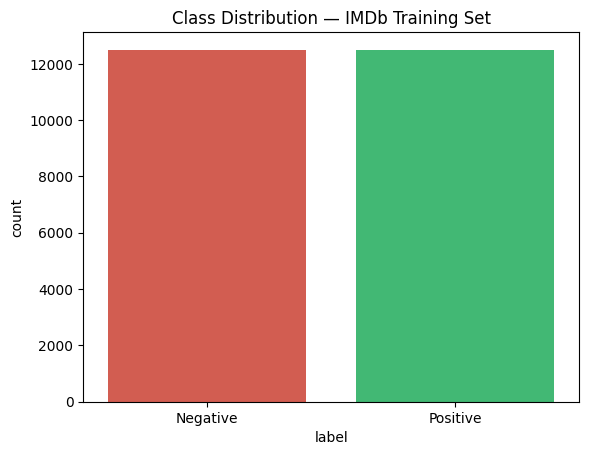

In [3]:

train_df = pd.DataFrame(dataset['train'])
print(train_df['label'].value_counts())
print("\n0 = Negative, 1 = Positive")

# Plot
sns.countplot(x='label', data=train_df, palette=['#E74C3C','#2ECC71'])
plt.xticks([0,1], ['Negative','Positive'])
plt.title('Class Distribution — IMDb Training Set')
plt.show()

In [4]:
for label, name in [(1, "POSITIVE"), (0, "NEGATIVE")]:
    print(f"\n{'='*50}")
    print(f"  {name} EXAMPLES")
    print(f"{'='*50}")
    examples = train_df[train_df['label'] == label].head(2)
    for _, row in examples.iterrows():
        print(f"\n{row['text'][:300]}...")


  POSITIVE EXAMPLES

Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik...

Zentropa is the most original movie I've seen in years. If you like unique thrillers that are influenced by film noir, then this is just the right cure for all of those Hollywood summer blockbusters clogging the theaters these days. Von Trier's follow-ups like Breaking the Waves have gotten more acc...

  NEGATIVE EXAMPLES

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...

"I Am Curious: Yellow" is a risible and pr

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


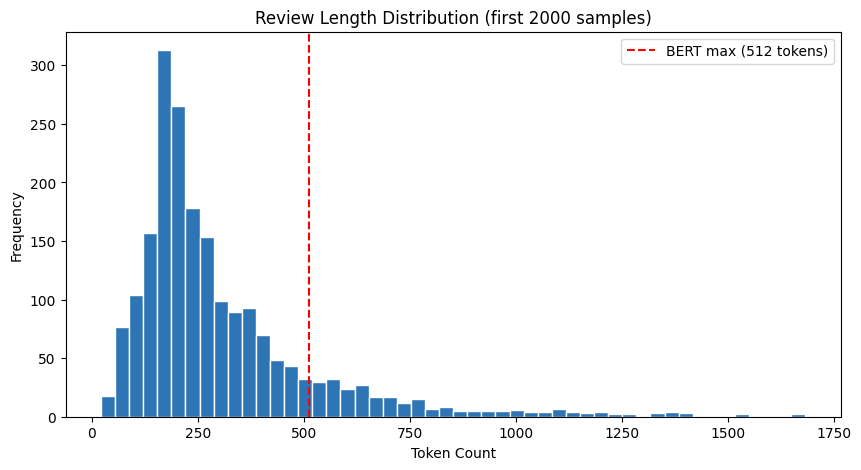

Average length : 305 tokens
Max length     : 1683 tokens
Reviews > 512  : 263 (13.2%)


In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

lengths = [len(tokenizer(text)['input_ids']) for text in train_df['text'][:2000]]

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=50, color='#2E75B6', edgecolor='white')
plt.axvline(512, color='red', linestyle='--', label='BERT max (512 tokens)')
plt.title('Review Length Distribution (first 2000 samples)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Average length : {sum(lengths)//len(lengths)} tokens")
print(f"Max length     : {max(lengths)} tokens")
print(f"Reviews > 512  : {sum(1 for l in lengths if l > 512)} ({sum(1 for l in lengths if l > 512)/len(lengths)*100:.1f}%)")

In [6]:
# Cell 6 — Clean & Save
print("Checking for nulls...")
print(train_df.isnull().sum())

# Remove empty reviews just in case
train_df = train_df[train_df['text'].str.strip() != '']
test_df = pd.DataFrame(dataset['test'])
test_df = test_df[test_df['text'].str.strip() != '']

print(f"\nClean train size: {len(train_df)}")
print(f"Clean test size:  {len(test_df)}")
print("\nAll good — dataset is clean!")

Checking for nulls...
text     0
label    0
dtype: int64

Clean train size: 25000
Clean test size:  25000

All good — dataset is clean!
